# Similarity-Pruned Dataset Workflow

Select one random anchor graph, compute vectorized embeddings for all graphs,
define a regression target as cosine similarity to that anchor,
remove the top-`k` most similar graphs, and continue with the pruned dataset.


In [17]:
%matplotlib inline
import math
import hashlib
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from NSPPK.nsppk import NSPPK

from coco_grape.visualizer.mol_display import draw_molecules


In [18]:
def plot_networkx_graphs(graphs, cmap='tab20', light=0.4, size=3.5, n_cols=None, show_label=True, color_offset=200, mode='not_molecule'):
    if len(graphs) == 0:
        print("No graphs to display.")
        return

    if mode == 'molecule':
        draw_molecules(graphs)
        return

    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)

    def lighten_color(color, amount):
        return tuple(channel + (1 - channel) * amount for channel in color[:3])

    def color_for_label(label):
        digest = hashlib.md5(str(label).encode("utf-8")).hexdigest()
        idx = (int(digest, 16) + color_offset) % cmap.N
        return lighten_color(cmap(idx), light)

    n_graphs = len(graphs)
    if n_cols is None:
        n_cols = n_graphs
    n_rows = math.ceil(n_graphs / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(size * n_cols, size * n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    elif n_rows == 1 or n_cols == 1:
        axes = np.array(axes).reshape(-1)
    else:
        axes = np.array(axes).reshape(-1)

    for i, graph in enumerate(graphs):
        ax = axes[i]
        labels = [graph.nodes[n].get('label', '?') for n in graph.nodes()]
        node_colors = [color_for_label(lbl) for lbl in labels]
        pos = nx.spring_layout(graph, seed=42)
        nx.draw_networkx(graph, pos=pos, node_color=node_colors, ax=ax, with_labels=show_label, font_size=8)
        ax.set_axis_off()

    for j in range(i + 1, len(axes)):
        axes[j].set_axis_off()

    plt.tight_layout()
    plt.show()


def infer_display_mode(graphs):
    if globals().get('DATASET_TYPE') == 'MOLECULAR':
        return 'molecule'
    for graph in graphs[:5]:
        if any('symbol' in attrs or 'atomic_num' in attrs for _, attrs in graph.nodes(data=True)):
            return 'molecule'
    return 'not_molecule'


In [19]:
# Configuration
DATASET_TYPE = 'MOLECULAR'  # 'MOLECULAR' or 'ARTIFICIAL'
DATASET_SIZE = 1600
RANDOM_STATE = 42
K_REMOVE = 5
REMOVE_ANCHOR = False
MAX_NODE_SIZE = 29

# Molecular loader config
ASSAY_ID = '651610'


In [20]:
def offset_neg_graphs(graphs, targets, offset=10):
    out_graphs = []
    for graph, target in zip(graphs, targets):
        graph_copy = graph.copy()
        if target == 0:
            for u in graph_copy.nodes():
                graph_copy.nodes[u]['label'] += offset
        out_graphs.append(graph_copy)
    return out_graphs, targets


def build_dataset(dataset_size=200, artificial_size=5):
    if DATASET_TYPE == 'ARTIFICIAL':
        from coco_grape.utils.artificial_graph_constructor import ArtificialGraphDatasetConstructor

        alphabet_size = 3
        graphs, targets = ArtificialGraphDatasetConstructor(
            graph_generator_target_type_pos='cycle',
            graph_generator_context_type_pos='cycle',
            graph_generator_target_type_neg='tree',
            graph_generator_context_type_neg='tree',
            target_size_pos=artificial_size,
            context_size_pos=artificial_size,
            n_link_edges_pos=1,
            alphabet_size_pos=alphabet_size,
            target_size_neg=artificial_size,
            context_size_neg=artificial_size,
            n_link_edges_neg=1,
            alphabet_size_neg=alphabet_size,
        ).sample(dataset_size // 2)
        graphs, targets = offset_neg_graphs(graphs, targets, offset=alphabet_size)
        return list(graphs), np.asarray(targets)

    if DATASET_TYPE == 'MOLECULAR':
        from coco_grape.data_loader.mol.mol_loader import PubChemLoader
        from coco_grape.data_loader.loader import SupervisedDataSetLoader

        def pubchem_loader():
            return PubChemLoader().load(ASSAY_ID)

        original_graphs, original_targets = SupervisedDataSetLoader(
            pubchem_loader,
            size=dataset_size,
            use_equalized=False,
        ).load()

        original_graphs = np.asarray(original_graphs, dtype=object)
        original_targets = np.asarray(original_targets)

        keep_indices = [
            idx for idx, graph in enumerate(original_graphs)
            if nx.number_of_nodes(graph) <= MAX_NODE_SIZE
        ]
        graphs = original_graphs[keep_indices].tolist()
        targets = original_targets[keep_indices]
        return graphs, targets

    raise ValueError(f"Unsupported DATASET_TYPE: {DATASET_TYPE}")


In [21]:
def compute_graph_embeddings(graphs, nbits=11):
    graph_vectorizer = NSPPK(
        radius=2,
        distance=4,
        connector=1,
        nbits=nbits,
        dense=True,
        parallel=True,
        use_edges_as_features=True,
    )
    embeddings = np.asarray(graph_vectorizer.fit_transform(graphs), dtype=np.float32)
    return graph_vectorizer, embeddings


def prune_by_anchor_similarity(graphs, targets, embeddings, k_remove=5, random_state=42, remove_anchor=False):
    if len(graphs) == 0:
        raise ValueError("Cannot prune an empty dataset.")
    if k_remove < 0:
        raise ValueError("k_remove must be >= 0.")
    if k_remove >= len(graphs):
        raise ValueError("k_remove must be smaller than the dataset size.")

    rng = np.random.default_rng(random_state)
    anchor_idx = int(rng.integers(low=0, high=len(graphs)))

    anchor_vec = embeddings[anchor_idx:anchor_idx + 1]
    similarity = cosine_similarity(embeddings, anchor_vec).ravel()

    ranking = np.argsort(-similarity)
    ordered = [idx for idx in ranking if (remove_anchor or idx != anchor_idx)]
    remove_indices = np.asarray(ordered[:k_remove], dtype=int)

    keep_mask = np.ones(len(graphs), dtype=bool)
    keep_mask[remove_indices] = False

    pruned_graphs = [g for g, keep in zip(graphs, keep_mask) if keep]
    pruned_targets = np.asarray([t for t, keep in zip(targets, keep_mask) if keep])
    pruned_similarity = similarity[keep_mask]

    removed_similarity = similarity[remove_indices]

    summary = pd.DataFrame({
        'graph_index': np.arange(len(graphs)),
        'target': targets,
        'cosine_to_anchor': similarity,
        'is_anchor': np.arange(len(graphs)) == anchor_idx,
        'removed': ~keep_mask,
    }).sort_values('cosine_to_anchor', ascending=False)

    return {
        'anchor_idx': anchor_idx,
        'anchor_graph': graphs[anchor_idx],
        'anchor_target': targets[anchor_idx],
        'similarity_target': similarity,
        'remove_indices': remove_indices,
        'removed_similarity': removed_similarity,
        'summary': summary,
        'pruned_graphs': pruned_graphs,
        'pruned_targets': pruned_targets,
        'pruned_similarity_target': pruned_similarity,
        'keep_mask': keep_mask,
    }


In [25]:
graphs, targets = build_dataset(dataset_size=DATASET_SIZE)
print(f"Loaded graphs: {len(graphs)}")
if len(targets) > 0:
    bincount = np.bincount(np.asarray(targets, dtype=int)) if np.issubdtype(np.asarray(targets).dtype, np.integer) else None
    if bincount is not None:
        print(f"Class split: {bincount}")

_, embeddings = compute_graph_embeddings(graphs, nbits=11)
print(f"Embeddings shape: {embeddings.shape}")

result = prune_by_anchor_similarity(
    graphs=graphs,
    targets=np.asarray(targets),
    embeddings=embeddings,
    k_remove=K_REMOVE,
    random_state=RANDOM_STATE,
    remove_anchor=REMOVE_ANCHOR,
)

print(f"Anchor index: {result['anchor_idx']} (target={result['anchor_target']})")
print(f"Removed graphs: {len(result['remove_indices'])}")
print(f"Remaining graphs: {len(result['pruned_graphs'])}")

display(result['summary'].head(12))


[18:16:42] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 6 ignored
[18:16:43] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 7 ignored
[18:16:43] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 7 ignored
[18:16:43] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 7 ignored
[18:16:43] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 9 ignored
[18:16:43] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 8 ignored
[18:16:43] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 9 ignored
[18:16:43] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 9 ignored
[18:16:47] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 8 ignored
[18:16:51] WARNING: not removing hydrogen atom without neighbors


Loaded graphs: 512
Class split: [410 102]
Embeddings shape: (512, 2048)
Anchor index: 45 (target=1)
Removed graphs: 5
Remaining graphs: 507


,graph_index,target,cosine_to_anchor,is_anchor,removed
45,45,1,1.000000,True,False
224,224,1,0.901645,False,True
298,298,1,0.899287,False,True
387,387,1,0.895687,False,True
340,340,0,0.893080,False,True
18,18,0,0.891978,False,True
501,501,1,0.890355,False,False
368,368,0,0.890094,False,False
370,370,0,0.889203,False,False
1,1,1,0.887816,False,False


Anchor graph:


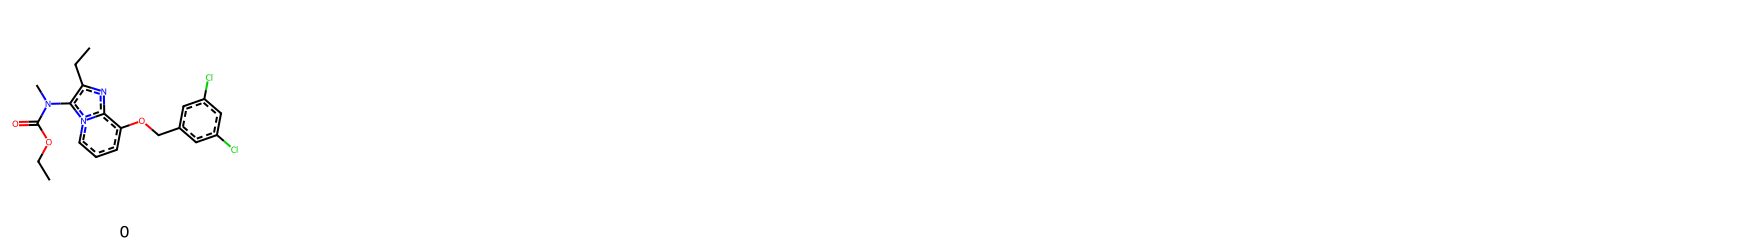

Removed top-5 most similar graphs:


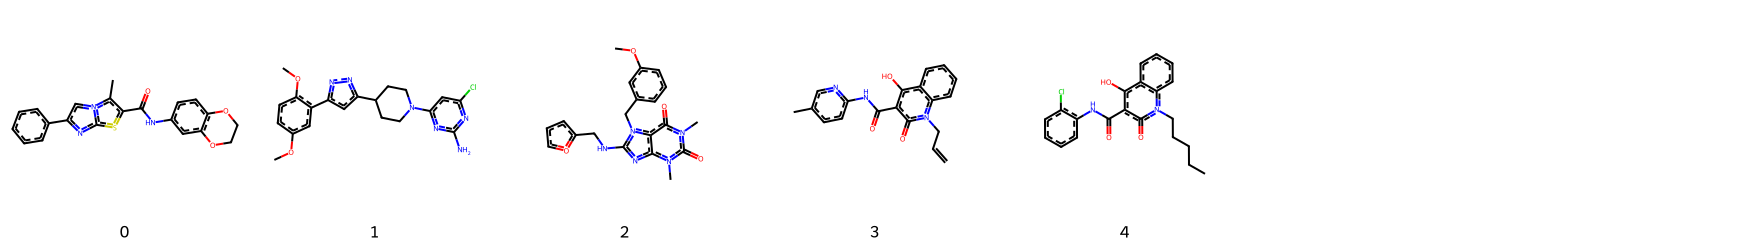

In [26]:
display_mode = infer_display_mode(graphs)

print("Anchor graph:")
plot_networkx_graphs([result['anchor_graph']], n_cols=1, mode=display_mode)

removed_graphs = [graphs[i] for i in result['remove_indices']]
print(f"Removed top-{len(removed_graphs)} most similar graphs:")
plot_networkx_graphs(removed_graphs, n_cols=max(1, len(removed_graphs)), mode=display_mode)


In [27]:
# Working dataset after similarity-based pruning
working_graphs = result['pruned_graphs']
working_targets = result['pruned_targets']
working_similarity_target = result['pruned_similarity_target']

print(f"working_graphs: {len(working_graphs)}")
print(f"working_targets: {len(working_targets)}")
print(f"working_similarity_target shape: {working_similarity_target.shape}")
print(f"cosine target range: [{working_similarity_target.min():.4f}, {working_similarity_target.max():.4f}]")


working_graphs: 507
working_targets: 507
working_similarity_target shape: (507,)
cosine target range: [0.6075, 1.0000]
